In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


# 13.1 — Transform , Dataset

In [3]:
train_dataset = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform
)
val_dataset = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

In [4]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 13.2 — CNN + weight_decay

In [5]:
class WeightDecayCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 13.3 — model, loss, optimizer, decive

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_weightDecay = WeightDecayCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_weightDecay.parameters(),
    lr=0.001,
    weight_decay=0.0001
)
print(model_weightDecay)

WeightDecayCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=7, bias=True)
  )
)


# 13.4 — Training loop 

In [8]:
num_epochs = 10
best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    model_weightDecay.train()
    running_train_loss = 0.0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_weightDecay(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # Validation
    model_weightDecay.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_weightDecay(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    # save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model_weightDecay.state_dict(),
            "best_weightDecay_model.pt"
        )
        print("  --> Best weightDecay model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("\nBest Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

  --> Best weightDecay model saved!
Epoch [1/10] Train Loss: 2.1482 Val Loss: 0.7848 Val Accuracy: 0.7158
  --> Best weightDecay model saved!
Epoch [2/10] Train Loss: 0.4695 Val Loss: 0.5946 Val Accuracy: 0.7907
  --> Best weightDecay model saved!
Epoch [3/10] Train Loss: 0.1745 Val Loss: 0.5689 Val Accuracy: 0.8127
  --> Best weightDecay model saved!
Epoch [4/10] Train Loss: 0.0717 Val Loss: 0.5775 Val Accuracy: 0.8243
  --> Best weightDecay model saved!
Epoch [5/10] Train Loss: 0.0197 Val Loss: 0.6455 Val Accuracy: 0.8320
  --> Best weightDecay model saved!
Epoch [6/10] Train Loss: 0.0071 Val Loss: 0.6109 Val Accuracy: 0.8437
Epoch [7/10] Train Loss: 0.0029 Val Loss: 0.6353 Val Accuracy: 0.8411
  --> Best weightDecay model saved!
Epoch [8/10] Train Loss: 0.0019 Val Loss: 0.6346 Val Accuracy: 0.8463
Epoch [9/10] Train Loss: 0.0015 Val Loss: 0.6626 Val Accuracy: 0.8424
  --> Best weightDecay model saved!
Epoch [10/10] Train Loss: 0.0011 Val Loss: 0.6642 Val Accuracy: 0.8514


Best Epoc

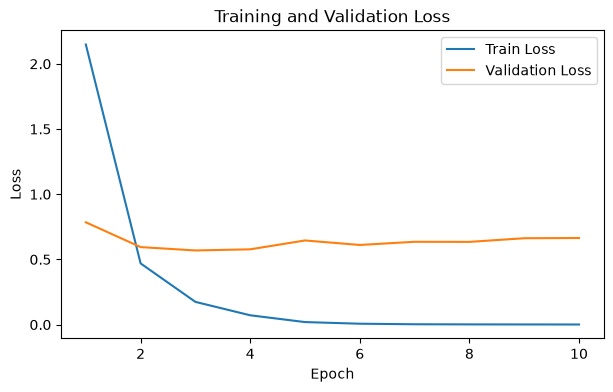

In [9]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

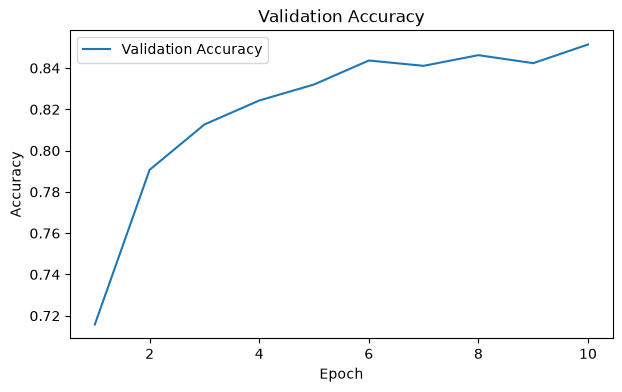

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 13.5 — Baseline evaluation on the validation set

In [11]:
model_weightDecay.load_state_dict(
    torch.load(
        'best_weightDecay_model.pt',
        map_location=device
    )
)
model_dropout = model_weightDecay.to(device)
model_dropout.eval()
print("Best weightDecay Model Loaded")

Best weightDecay Model Loaded


In [12]:
all_predictions_weightDecay = []
all_labels_weightDecay  = []
model_weightDecay.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_dropout(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_weightDecay.extend(predictions.cpu().numpy())
        all_labels_weightDecay.extend(labels.cpu().numpy())

print("Predictions:", len(all_predictions_weightDecay))
print("Labels:", len(all_labels_weightDecay))

Predictions: 774
Labels: 774


# 12.6 — Precision , Recall , F1 , confusion_matrix

In [13]:
accuracy = accuracy_score(all_labels_weightDecay, all_predictions_weightDecay)
precision = precision_score(all_labels_weightDecay, all_predictions_weightDecay, average="macro")
recall = recall_score(all_labels_weightDecay, all_predictions_weightDecay, average="macro")
f1 = f1_score(all_labels_weightDecay, all_predictions_weightDecay, average="macro")
cm = confusion_matrix(all_labels_weightDecay, all_predictions_weightDecay)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.851421188630491
Validation Precision: 0.8661977642406905
Validation Recall   : 0.8440382711753045
Validation F1 Score : 0.853487255733595
confusion_matrix    :
 [[ 53   1  12   2   1   0   3]
 [  0  78  10   1   1   2   1]
 [  6   2 164   6   2   1   8]
 [  0   0  13  65   0   0   0]
 [  2   0   1   1  87   1   8]
 [  0   1   2   2   4  88   0]
 [  1   0   9   0  10   1 124]]


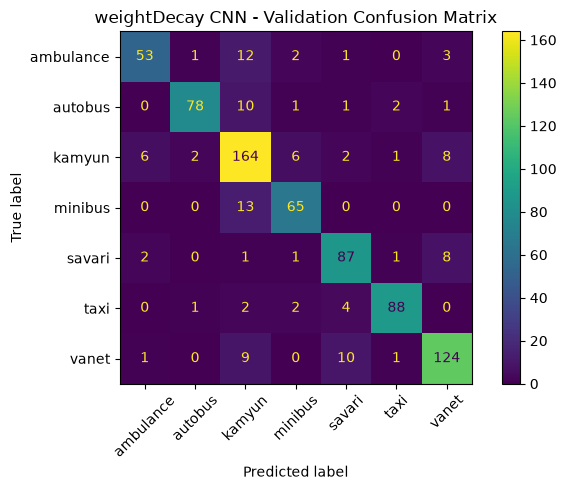

In [14]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("weightDecay CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [15]:
report = classification_report(all_labels_weightDecay, all_predictions_weightDecay, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.85      0.74      0.79        72
     autobus       0.95      0.84      0.89        93
      kamyun       0.78      0.87      0.82       189
     minibus       0.84      0.83      0.84        78
      savari       0.83      0.87      0.85       100
        taxi       0.95      0.91      0.93        97
       vanet       0.86      0.86      0.86       145

    accuracy                           0.85       774
   macro avg       0.87      0.84      0.85       774
weighted avg       0.86      0.85      0.85       774

